# Libraries & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import json

In [3]:
from pytrends.request import TrendReq

# Importing Data

In [4]:
# ============================================================
# LOAD DATA
# ============================================================

DATA_PATH = 'Analysis/Data'

merc_results              = pd.read_csv(f'{DATA_PATH}/merc_results.csv')
rookie_df_gen_talent      = pd.read_csv(f'{DATA_PATH}/rookie_df_gen_talent.csv')
teammate_df_gen_talent    = pd.read_csv(f'{DATA_PATH}/teammate_df_gen_talent.csv')
rookie_df_2025            = pd.read_csv(f'{DATA_PATH}/rookie_df_2025.csv')
teammate_df_2025          = pd.read_csv(f'{DATA_PATH}/teammate_df_2025.csv')

with open(f'{DATA_PATH}/driver_metadata.json') as f:
    meta = json.load(f)

drivers            = meta['drivers']
teammate_names     = meta['teammate_names']
rookie_years       = meta['rookie_years']
rookies_2025       = meta['rookies_2025']
primary_teammates  = meta['primary_teammates']


# Defining Constants

In [5]:
teammate_experience_gen_talent = {
    'Hamilton': 7,    # Alonso — 2001 debut, 2007 was his 7th season, 2x world champion
    'Verstappen': 1,  # Sainz — also a rookie in 2015, first season
    'Norris': 5,      # Sainz — 2015 debut, 2019 was his 5th season
    'Antonelli': 7,   # Russell — 2019 debut, 2025 was his 7th season
    'Leclerc':5       # Ericsson - 2014 debut, 2018 was his 5th season
}

In [6]:
# Derive 2025 rookie teammate names from primary_teammates
abbr_to_name = {
    'RUS': 'Russell',
    'LAW': 'Lawson',
    'HUL': 'Hulkenberg',
    'OCO': 'Ocon'
}

teammate_names_2025 = {
    name: abbr_to_name[abbr] 
    for name, abbr in primary_teammates.items()
}

In [7]:
teammate_experience_2025_rookies = {
    'Antonelli': 7,   # Russell — 2019 debut, 2025 is his 7th season
    'Hadjar':    2,   # Lawson — 2023 debut in August, 2025 is his 2nd full season  
    'Bortoleto': 13,  # Hulkenberg — 2010 debut, 2025 is his 10th season (with gaps)
    'Bearman':   9    # Ocon — debuted 2017, 9 seasons in F1
}

In [8]:
# Driver colours for charts
DRIVER_COLOURS = {
    'ANT': '#00D2BE', 'Antonelli': '#00D2BE',
    'RUS': '#FF8700', 'Russell':   '#FF8700',
    'Hadjar':    '#DC0000',
    'Bortoleto': '#0600EF',
    'Bearman':   '#FF1E00'
}

# Data Cleaning / Preprocessing

In [9]:
merc_results['EventDate'] = pd.to_datetime(merc_results['EventDate'])
merc_results['RaceLabel'] = (
    merc_results['Season'].astype(str).str[-2:] + ' ' +
    merc_results['EventName']
    .str.replace(' Grand Prix', '')
    .str.replace(' Prix', '')
)

# Split into Antonelli and Russell for easy access
ant = merc_results[merc_results['Abbreviation'] == 'ANT'].copy()
rus = merc_results[merc_results['Abbreviation'] == 'RUS'].copy()

# Clean 2025 rookie df
rookie_df_2025 = rookie_df_2025.rename(columns={
    'RookiePosition': 'Position',
    'GridPosition':   'Grid'
})

# Clean 2025 teammate df
teammate_df_2025 = teammate_df_2025.rename(columns={
    'Position':    'TeammatePosition',
    'GridPosition':'TeammateGrid'
})

# Helper Functions

Key metrics we're interested in to study season performance
- median start position
- median finish position
- places gained
- Std dev of final position (consistency)

Key metrics we're interested in to study performance vs. teammate
- %times beat teammate
- positions gained
- positions gained weighted by teammate experience (# seasons in F1)

In [10]:
def get_season_summary(driver_name, df, position_col='Position', grid_col='Grid',
                       season_col='Season', split_phases=False, n_phases=4,
                       include_all_seasons=False):
    d = df[df['Driver'] == driver_name].copy().reset_index(drop=True)
    d['PlacesGained'] = d[grid_col] - d[position_col]

    if not include_all_seasons:
        d = d[d[season_col] == d[season_col].min()]

    results = []

    for year in sorted(d[season_col].unique()):
        year_df = d[d[season_col] == year].reset_index(drop=True)
        n = len(year_df)

        if split_phases and n >= 6:
            phase_size = n // n_phases
            bins = [-1] + [phase_size * i - 1 for i in range(1, n_phases + 1)]
            bins[-1] = n - 1
            phase_ranges = []
            for i in range(n_phases):
                start = i * phase_size + 1
                end = (i + 1) * phase_size if i < n_phases - 1 else n
                phase_ranges.append(f'{year} Races {start}–{end}')
            year_df['Phase'] = pd.cut(year_df.index, bins=bins, labels=phase_ranges)

            for phase, phase_df in year_df.groupby('Phase', observed=True):
                results.append({
                    'Driver': driver_name,
                    'Phase': str(phase),
                    'Races': len(phase_df),
                    'MedianStartPosition': phase_df[grid_col].median(),
                    'MedianFinishPosition': phase_df[position_col].median(),
                    'MedianPlacesGained': phase_df['PlacesGained'].median(),
                    'StdPosition': round(phase_df[position_col].std(), 2)
                })
        else:
            results.append({
                'Driver': driver_name,
                'Phase': str(year),
                'Races': n,
                'MedianStartPosition': year_df[grid_col].median(),
                'MedianFinishPosition': year_df[position_col].median(),
                'MedianPlacesGained': year_df['PlacesGained'].median(),
                'StdPosition': round(year_df[position_col].std(), 2)
            })

    return pd.DataFrame(results)

In [11]:
def get_teammate_comparison(driver_name, rookie_df, teammate_df,
                            position_col='Position', season_col='Year'):
    r = rookie_df[rookie_df['Driver'] == driver_name].copy()
    t = teammate_df[teammate_df['Driver'] == driver_name].copy()

    merged = r.merge(
        t[['Round', season_col, 'TeammatePosition']],
        on=['Round', season_col], how='left'
    )
    merged['PositionDelta'] = merged['TeammatePosition'] - merged[position_col]
    debut_year = merged[season_col].min()
    merged = merged[merged[season_col] == debut_year]

    return pd.DataFrame([{
        'Driver': driver_name,
        'MedianDelta': merged['PositionDelta'].median(),
        'BeatTeammate%': round((merged['PositionDelta'] > 0).mean() * 100, 1)
    }])

# The Analysis

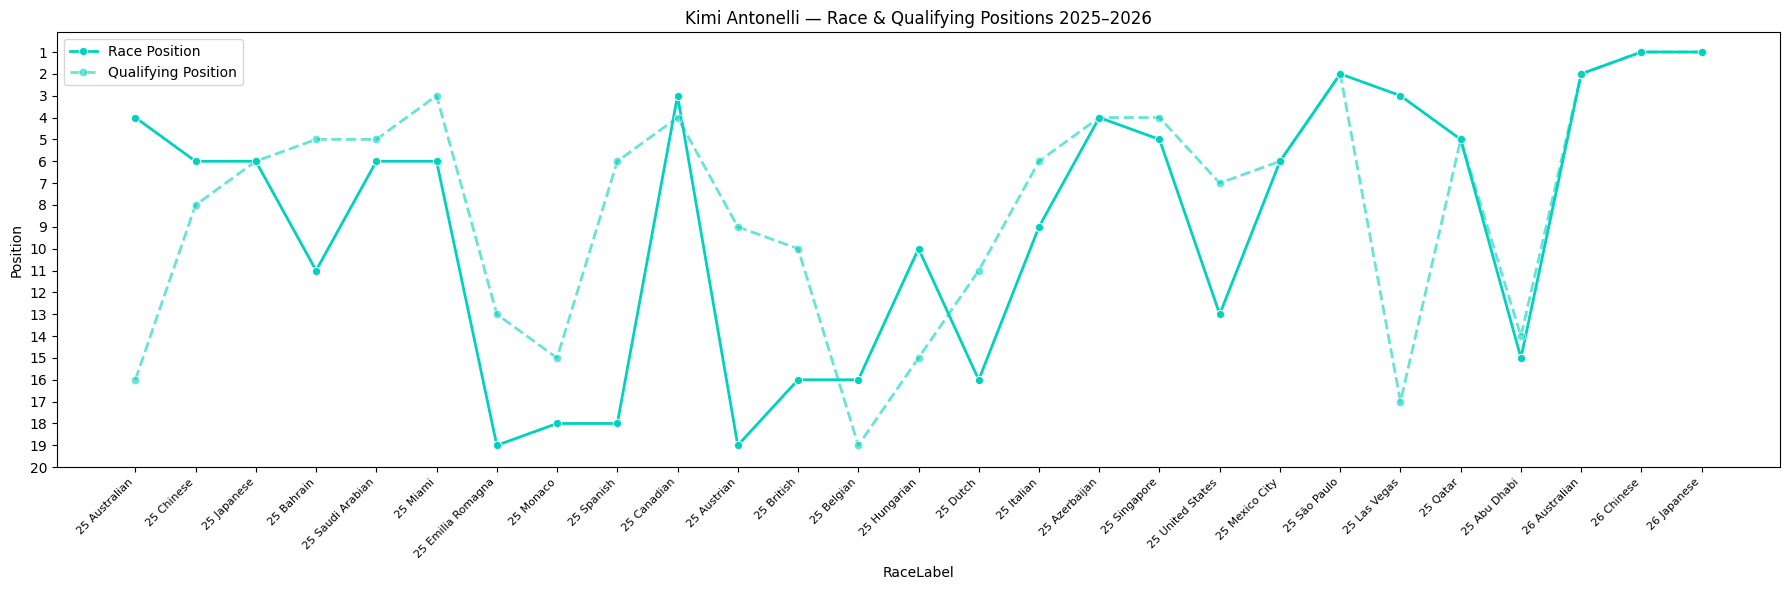

,Driver,Phase,Races,MedianStartPosition,MedianFinishPosition,MedianPlacesGained,StdPosition
0,Antonelli,2025 Races 1–6,6,5.5,6.0,-0.5,2.35
1,Antonelli,2025 Races 7–12,6,9.5,18.0,-6.0,6.22
2,Antonelli,2025 Races 13–18,6,8.5,9.5,-0.5,5.18
3,Antonelli,2025 Races 19–24,6,6.5,5.5,0.0,5.39
4,Antonelli,2026,3,1.0,1.0,0.0,0.58


In [12]:
# ============================================================
# PART 1 — ANTONELLI'S OWN PERFORMANCE ARC
# ============================================================

ant_summary = get_season_summary(
    'Antonelli', ant,
    position_col='Position', grid_col='GridPosition', season_col='Season',
    split_phases=True, include_all_seasons=True
)

# Chart — race & qualifying positions
fig, ax = plt.subplots(figsize=(18, 6))

sns.lineplot(data=ant, x='RaceLabel', y='Position',
             marker='o', color='#00D2BE', linewidth=2, label='Race Position', ax=ax)
sns.lineplot(data=ant, x='RaceLabel', y='GridPosition',
             marker='o', color='#00D2BE', linewidth=2, linestyle='--',
             label='Qualifying Position', alpha=0.6, ax=ax)

ax.invert_yaxis()
ax.set_yticks(range(1, 21))
ax.set_ylabel('Position')
ax.set_title('Kimi Antonelli — Race & Qualifying Positions 2025–2026')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

ant_summary

**From the graph**
- Visually we immediately see a lot of variability
- Qualifying vs. race performance also seems to vary

**Metrics align well with the graph**
- *R1-6 — Steady start* - Median finish P6, losing half a place from grid, std of 2.35. Consistent and competitive. Finishing where he starts, in the points, with very little variance. Exactly what you'd want from a rookie settling in.
- *R7-12 — Turbulent middle* - Median finish crashes to P18, losing 6 places from grid, std spikes to 6.22. Every metric at its worst simultaneously. He's still generally making it to Q3 in qualifying but race performance is very poor. This is the most volatile phase by every measure.
- *R13-18 — Results recover, consistency doesn't* - More points finishes than not, places gained back to -0.5 — almost identical to R1-6. On the surface a full recovery. But std remains elevated at 5.18, nearly double the opening phase. The results look better but the unpredictability hasn't resolved — the team still doesn't know what they're getting each weekend.
- *R19-24 — More improvement* - Big improvement with results closer to the start fo the season. Median finish improves to P5.5, neutral on places gained. Comfortably in the points. But std barely moves at 5.39 — consistency remains the unresolved issue until the end of the entire 2025 season.
- *2026 — Different driver (but also very different car!)* - Median finish P1, neutral on places gained, std of 0.58. The variance that defined his entire 2025 season seems resolved at least in terms of where the car ends. He's starting at the front and finishing at the front with almost no deviation. We know the car has significantly improved, and we know he has dropped some places mid race and gained it back (somewhat because the pace has been so good, but also undeniably because he is driving better!)



In [13]:
# ============================================================
# PART 2 — ANTONELLI VS RUSSELL
# ============================================================

rus_summary = get_season_summary(
    'Russell', rus,
    position_col='Position', grid_col='GridPosition', season_col='Season',
    split_phases=True, include_all_seasons=True
)

# Combined phase table
combined = pd.concat([ant_summary, rus_summary], ignore_index=True)
combined = combined.rename(columns={
    'MedianStartPosition':  'Median Grid',
    'MedianFinishPosition': 'Median Finish',
    'MedianPlacesGained':   'Places Gained/Lost',
    'StdPosition':          'Consistency (lower = more predictable)'
})

combined[['Driver', 'Phase', 'Races', 'Median Grid',
                'Median Finish', 'Places Gained/Lost',
                'Consistency (lower = more predictable)']]

,Driver,Phase,Races,Median Grid,Median Finish,Places Gained/Lost,Consistency (lower = more predictable)
0,Antonelli,2025 Races 1–6,6,5.5,6.0,-0.5,2.35
1,Antonelli,2025 Races 7–12,6,9.5,18.0,-6.0,6.22
2,Antonelli,2025 Races 13–18,6,8.5,9.5,-0.5,5.18
3,Antonelli,2025 Races 19–24,6,6.5,5.5,0.0,5.39
4,Antonelli,2026,3,1.0,1.0,0.0,0.58
5,Russell,2025 Races 1–6,6,3.5,3.0,0.5,1.22
6,Russell,2025 Races 7–12,6,4.0,6.0,0.0,3.78
7,Russell,2025 Races 13–18,6,5.0,3.5,1.0,1.63
8,Russell,2025 Races 19–24,6,4.0,5.5,-1.5,1.79
9,Russell,2026,3,2.0,2.0,0.0,1.53


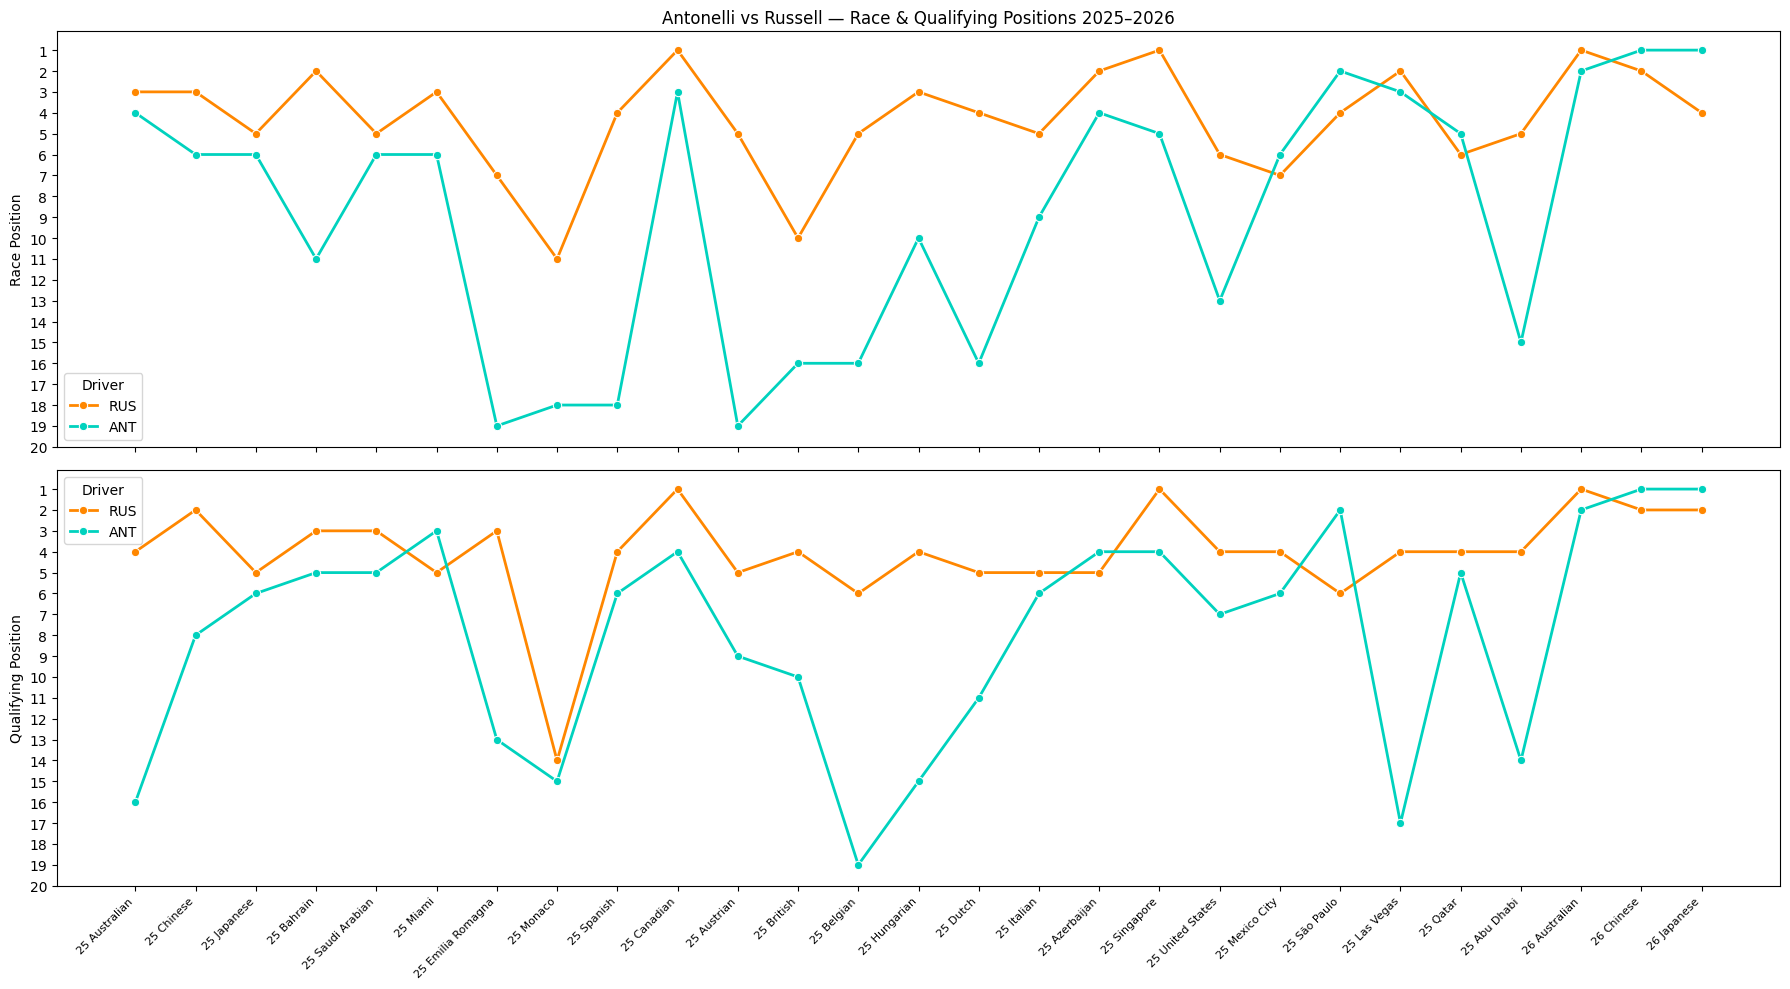

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --- Race Position ---
sns.lineplot(data=merc_results, x='RaceLabel', y='Position',
             hue='Abbreviation', marker='o',
             palette={'ANT': '#00D2BE', 'RUS': '#FF8700'},
             linewidth=2, ax=ax1)
ax1.invert_yaxis()
ax1.set_yticks(range(1, 21))
ax1.set_ylabel('Race Position')
ax1.set_title('Antonelli vs Russell — Race & Qualifying Positions 2025–2026')
ax1.legend(title='Driver')

# --- Qualifying Position ---
sns.lineplot(data=merc_results, x='RaceLabel', y='GridPosition',
             hue='Abbreviation', marker='o',
             palette={'ANT': '#00D2BE', 'RUS': '#FF8700'},
             linewidth=2, ax=ax2)
ax2.invert_yaxis()
ax2.set_yticks(range(1, 21))
ax2.set_ylabel('Qualifying Position')
ax2.set_xlabel('')
ax2.legend(title='Driver')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

**In comparison to Russell**
- Russell continuously outperforming Kimi in  both qualifying and the race (expected)
- Russell also showing much more consistency across his performances (signs of experience)

- Russell showing really good performance through the 2025 and 2026 seasons. Low variability, generally gaining places across the race and also consistently scoring points and even being in the top 5.
- Antonelli's variance was specific to him, not the car or reliability
- By 2026 Antonelli's std drops to 0.58, actually better than Russell's 1.53

# Part 3: Rookie comparison for 2025 season

In [15]:
# ============================================================
# PART 3 — 2025 ROOKIE CLASS COMPARISON
# ============================================================

# Season summary for each rookie
rookie_summary_2025 = pd.concat([
    get_season_summary(name, rookie_df_2025,
                      position_col='Position', grid_col='Grid',
                      season_col='Year', split_phases=False)
    for name in rookies_2025.keys()
], ignore_index=True)

# Teammate comparison for each rookie
rookie_teammate_comparison_2025 = pd.concat([
    get_teammate_comparison(name, rookie_df_2025, teammate_df_2025,
                           position_col='Position', season_col='Year')
    for name in rookies_2025.keys()
], ignore_index=True)

# Combine
rookie_summary_2025 = rookie_summary_2025.merge(rookie_teammate_comparison_2025, on='Driver')
rookie_summary_2025['Teammate'] = rookie_summary_2025['Driver'].map(teammate_names_2025)
rookie_summary_2025['TeammateExperience'] = rookie_summary_2025['Driver'].map(
    teammate_experience_2025_rookies
)
rookie_summary_2025['AdjustedDelta'] = (
    rookie_summary_2025['MedianDelta'] / rookie_summary_2025['TeammateExperience']
).round(2)
rookie_summary_2025['RookieYear'] = '2025'

rookie_summary_2025[['Driver', 'RookieYear','Teammate', 'TeammateExperience',
                            'StdPosition','MedianDelta',
                            'AdjustedDelta', 'BeatTeammate%']]

,Driver,RookieYear,Teammate,TeammateExperience,StdPosition,MedianDelta,AdjustedDelta,BeatTeammate%
0,Antonelli,2025,Russell,7,5.89,-4.0,-0.57,12.5
1,Hadjar,2025,Lawson,2,4.58,2.0,1.00,66.7
2,Bortoleto,2025,Hulkenberg,13,4.06,-1.5,-0.12,45.8
3,Bearman,2025,Ocon,9,4.18,0.0,0.00,50.0


In [16]:
# ============================================================
# PART 4 — GENERATIONAL TALENT COMPARISON
# ============================================================

gen_drivers = list(drivers.keys())

season_summary = pd.concat([
    get_season_summary(d, rookie_df_gen_talent,
                      position_col='Position', grid_col='Grid',
                      season_col='Year', split_phases=False)
    for d in gen_drivers
], ignore_index=True)

teammate_comparison = pd.concat([
    get_teammate_comparison(d, rookie_df_gen_talent, teammate_df_gen_talent,
                           position_col='Position', season_col='Year')
    for d in gen_drivers
], ignore_index=True)

gen_talents = season_summary.merge(teammate_comparison, on='Driver')
gen_talents['Teammate'] = gen_talents['Driver'].map(teammate_names)
gen_talents['RookieYear'] = gen_talents['Driver'].map(
    {d: info[0] for d, info in drivers.items()}
)
gen_talents['TeammateExperience'] = gen_talents['Driver'].map(teammate_experience_gen_talent)
gen_talents['AdjustedDelta'] = (
    gen_talents['MedianDelta'] / gen_talents['TeammateExperience']
).round(2)

gen_talents[['Driver', 'RookieYear', 'Teammate', 'TeammateExperience',
                   'StdPosition',
                   'MedianDelta', 'AdjustedDelta', 'BeatTeammate%']]

,Driver,RookieYear,Teammate,TeammateExperience,StdPosition,MedianDelta,AdjustedDelta,BeatTeammate%
0,Hamilton,2007,Alonso,7,4.46,-1.0,-0.14,41.2
1,Verstappen,2015,Sainz,1,4.46,1.0,1.00,57.9
2,Leclerc,2018,Ericsson,5,4.76,2.0,0.40,57.1
3,Norris,2019,Sainz,5,4.83,-3.0,-0.60,38.1


Looking at this we choose to exclude Leclerc and Verstappen as it wouldn't be a fair comparison
- Ericsson was a consistent backmarker, 2018 was in fact this last season in F1 (while all the others are still competing in F1)
- Verstappen debuted alongside a rookie, so performance gap calculations are not meaningful 

In [17]:
gen_talents=gen_talents[(gen_talents.Driver!="Leclerc") & (gen_talents.Driver!="Verstappen")]

In [18]:
rookies_2025_vs_gen_talents =pd.concat([
    rookie_summary_2025[['Driver', 'RookieYear', 'Teammate', 'TeammateExperience',
                         'MedianPlacesGained', 'StdPosition',
                         'MedianDelta', 'AdjustedDelta', 'BeatTeammate%']],
    
    gen_talents[['Driver', 'RookieYear', 'Teammate', 'TeammateExperience',
                 'MedianPlacesGained', 'StdPosition',
                 'MedianDelta', 'AdjustedDelta', 'BeatTeammate%']]
], ignore_index=True)

rookies_2025_vs_gen_talents


,Driver,RookieYear,Teammate,TeammateExperience,MedianPlacesGained,StdPosition,MedianDelta,AdjustedDelta,BeatTeammate%
0,Antonelli,2025,Russell,7,-1.0,5.89,-4.0,-0.57,12.5
1,Hadjar,2025,Lawson,2,-1.0,4.58,2.0,1.00,66.7
2,Bortoleto,2025,Hulkenberg,13,0.0,4.06,-1.5,-0.12,45.8
3,Bearman,2025,Ocon,9,2.0,4.18,0.0,0.00,50.0
4,Hamilton,2007,Alonso,7,0.0,4.46,-1.0,-0.14,41.2
5,Norris,2019,Sainz,5,-1.0,4.83,-3.0,-0.60,38.1


**Comparing Antonelli to the benchmarks** 
- Hamilton set the benchmark — almost matching his teammate race by race, beating him 41% of the time.
- Overall, after adjusting for teammate experience, Norris and Antonelli closed the gap to their teammates by a similar margin (in terms of positions) in a typical race. On that measure alone, they are comparable rookies.
- But Norris beat Sainz 38% of races — similar to Hamilton's 41%. Antonelli beat Russell only 12.5% of the time.
- The explanation lies in consistency. Norris was generally as consistent as Hamilton but Antonelli was the most inconsistent of the three, swinging more wildly race to race.
- Norris was reliably close to Sainz, and that closeness occasionally tipped in his favour. Antonelli was sometimes close to Russell and sometimes far off — the unpredictability meant he rarely sustained enough momentum to actually come out ahead.

# Part 5: Media analysis of rookies
We tried doing a few things to understand how the media was talking about Antonelli.
- Mediacloud --> not enough data found
- Scraping driectly from major websites like BBC Sport etc. - request got blocked

So we just decided to stick to studying Google trends, specifically Antonelli trends and searches as a fraction of overall interest in F1.

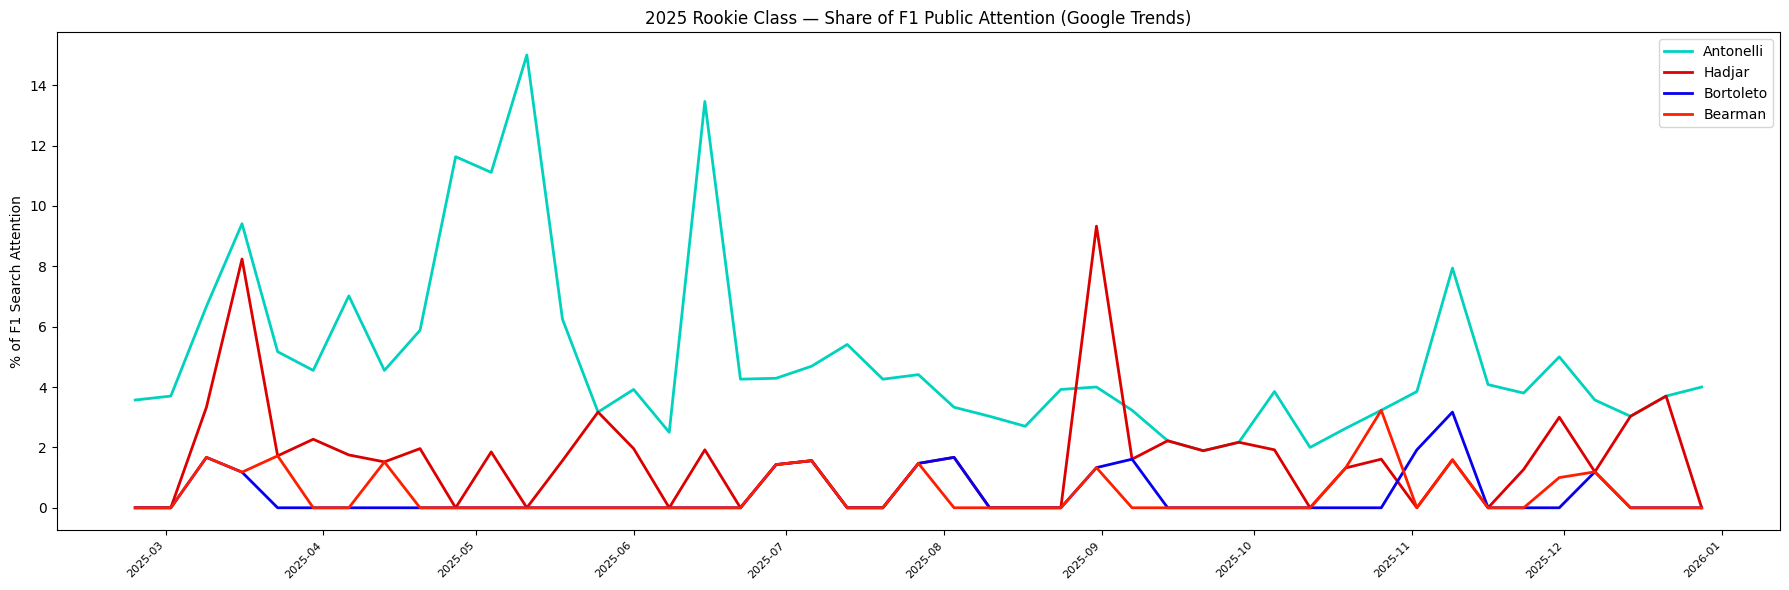

In [19]:
# ============================================================
# PART 5 — GOOGLE TRENDS / PUBLIC ATTENTION
# ============================================================

pytrends = TrendReq(hl='en-US', tz=0)

# Pull attention share for each rookie normalised against Formula 1
search_terms = {
    'Antonelli': 'Kimi Antonelli',
    'Hadjar':    'Isack Hadjar',
    'Bortoleto': 'Gabriel Bortoleto',
    'Bearman':   'Oliver Bearman'
}

shares = {}
for name, search_term in search_terms.items():
    pytrends.build_payload(
        kw_list=[search_term, 'Formula 1'],
        timeframe='2025-03-01 2025-12-31',
        geo=''
    )
    df = pytrends.interest_over_time().drop(columns=['isPartial'])
    shares[name] = (df[search_term] / df['Formula 1'].replace(0, 1) * 100).round(2)

shares_df = pd.DataFrame(shares)
shares_df.index = pd.to_datetime(shares_df.index)

# Chart — rookie attention shares
fig, ax = plt.subplots(figsize=(18, 6))

for driver, color in DRIVER_COLOURS.items():
    if driver in shares_df.columns:
        sns.lineplot(data=shares_df, x=shares_df.index, y=driver,
                    color=color, linewidth=2, label=driver, ax=ax)

ax.set_title('2025 Rookie Class — Share of F1 Public Attention (Google Trends)')
ax.set_ylabel('% of F1 Search Attention')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


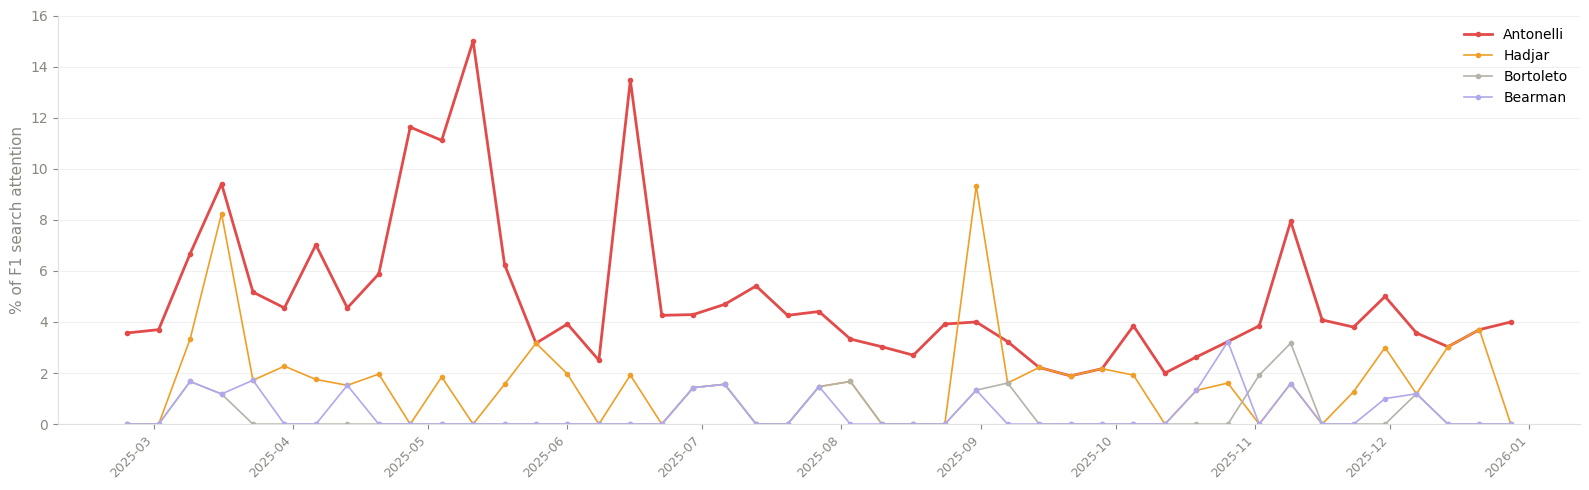

In [21]:
fig, ax = plt.subplots(figsize=(16, 5))

colors = {
    'Antonelli': '#E24B4A',
    'Hadjar':    '#EF9F27', 
    'Bortoleto': '#B4B2A9',
    'Bearman':   '#AFA9EC'
}

for driver, color in colors.items():
    ax.plot(shares_df.index, shares_df[driver], 
            color=color, linewidth=2 if driver == 'Antonelli' else 1.2,
            marker='o', markersize=3, label=driver)

ax.set_ylabel('% of F1 search attention', fontsize=11, color='#888780')
ax.set_xlabel('')
ax.set_ylim(0, 16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e0e0e0')
ax.spines['bottom'].set_color('#e0e0e0')
ax.tick_params(colors='#888780')
ax.yaxis.grid(True, color='#f0f0f0')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()